<a href="https://colab.research.google.com/github/VarsanJ/Cities-in-Motion-2026/blob/main/CatBoostModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0:	learn: 2.1186814	total: 18.8ms	remaining: 37.7s
200:	learn: 1.0850736	total: 4.32s	remaining: 38.6s
400:	learn: 0.8970255	total: 8.2s	remaining: 32.7s
600:	learn: 0.7579582	total: 11.5s	remaining: 26.9s
800:	learn: 0.6492159	total: 14.9s	remaining: 22.3s
1000:	learn: 0.5541873	total: 19.8s	remaining: 19.8s
1200:	learn: 0.4808174	total: 23.2s	remaining: 15.5s
1400:	learn: 0.4157697	total: 26.7s	remaining: 11.4s
1600:	learn: 0.3614872	total: 31.3s	remaining: 7.8s
1800:	learn: 0.3188457	total: 35.1s	remaining: 3.88s
1999:	learn: 0.2826874	total: 38.6s	remaining: 0us

--- Feature Importance ---


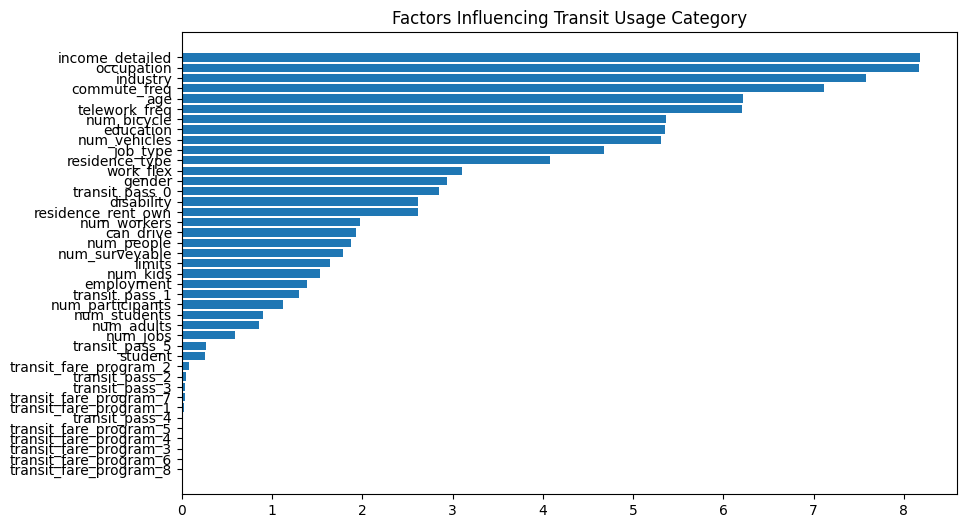


--- SHAP Summary Plot ---


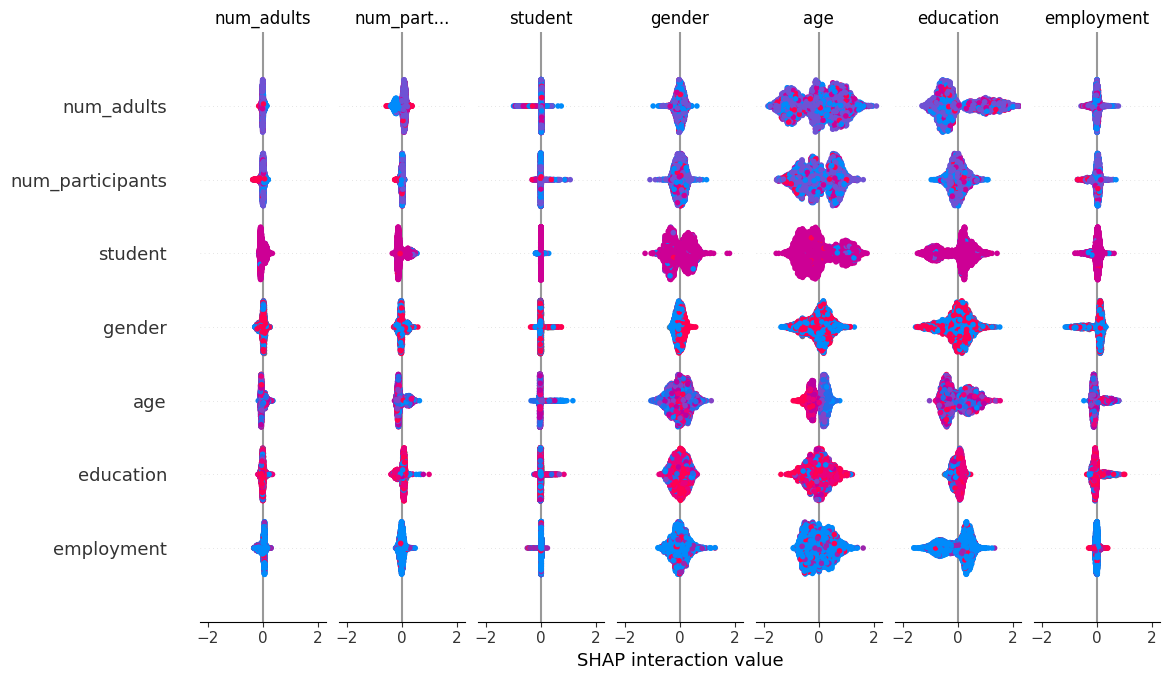


--- Partial Dependence for telework_freq ---


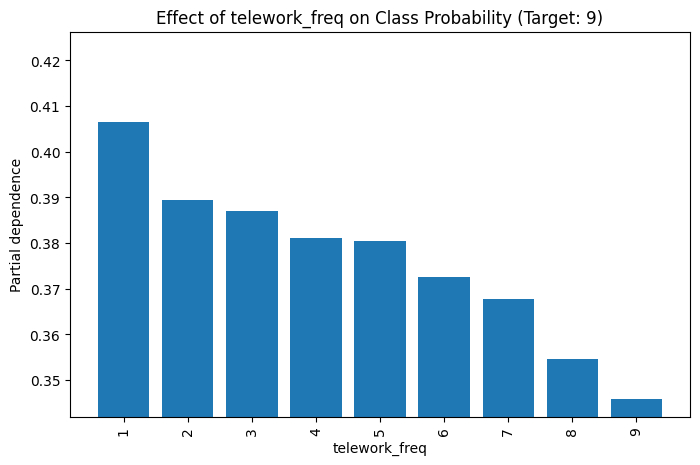

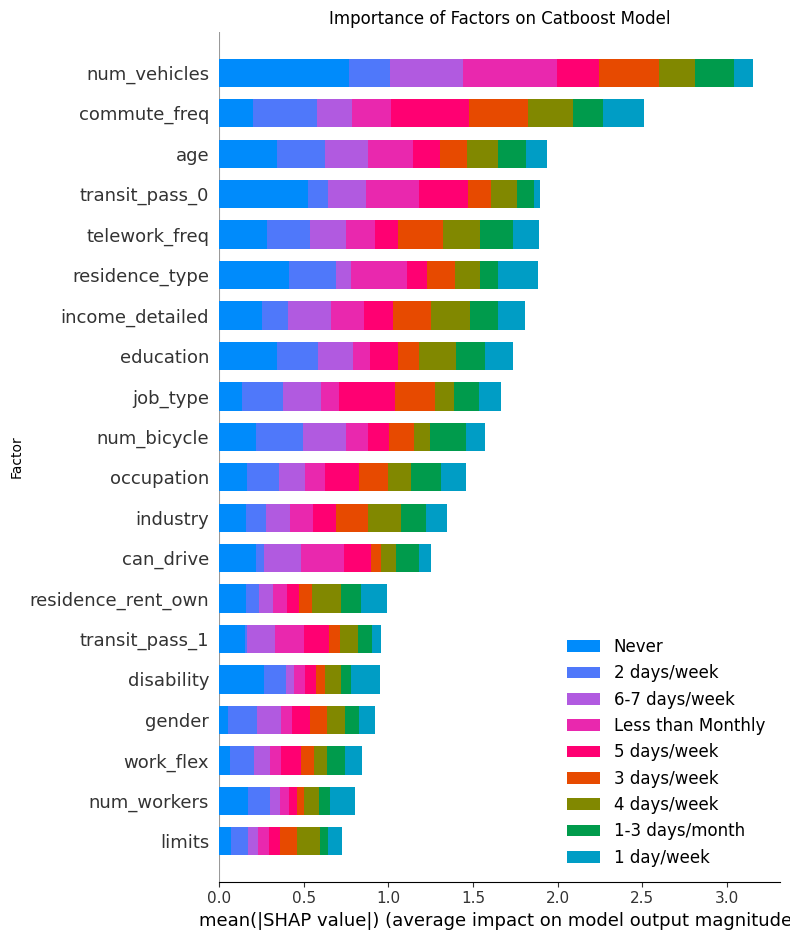

In [12]:
!pip install catboost shap -q

# Imports
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# File Import
fileImport = pd.read_csv("CMAP_NeededVariables.csv")

# Define The Dependent and Independent Variable so far
dependent_var = 'transit_freq'
independent_var = 'telework_freq'
dependent_labels = [
    "6-7 days/week",
    "5 days/week",
    "4 days/week",
    "3 days/week",
    "2 days/week",
    "1 day/week",
    "1-3 days/month",
    "Less than Monthly",
    "Never"
]

# Handle Special Code Cases in a copy
fileImport_cleaned = fileImport.copy()
# Replace the 996 with 9 (Never)
fileImport_cleaned[dependent_var] = fileImport_cleaned[dependent_var].replace(996, 9)
# General custom codes for invalid responses
custom_codes = [995, 997, 998, 999, -1]
fileImport_cleaned = fileImport_cleaned.replace(custom_codes, np.nan)

fileImport_cleaned[independent_var] = fileImport_cleaned[independent_var].replace(
    [995, 996, 997, 998, 999, -1], np.nan
)

# Cleans variables
df = fileImport_cleaned.dropna(subset=[dependent_var]) # Can't train on NaN targets
X = df.drop(columns=[dependent_var, 'hh_id', 'home_tract_2020', 'work_tract_2020', 'person_weight']) # Drops hh_id as well, not to consider
y = df[dependent_var]

# Categorical Columns
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Create Classification Model
model = CatBoostClassifier(
    iterations=2000, #
    learning_rate=0.05, #
    depth=6, #
    loss_function='MultiClass', # Use MultiClass for categorical frequency levels
    random_seed=42,
    nan_mode='Min', #
    verbose=200 # Print outputs
)

# Model Training
model.fit(X, y, cat_features=cat_features)

# These graphs were asked by Masoud, some AI Generated below

# Feature Importance Plot
print("\n--- Feature Importance ---")
importance = model.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 6))
plt.barh(importance['Feature Id'][::-1], importance['Importances'][::-1])
plt.title("Factors Influencing Transit Usage Category")
plt.show()

# SHAP Value Summary Plot
print("\n--- SHAP Summary Plot ---")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

# Partial Dependence Plot For telework_freq
print(f"\n--- Partial Dependence for {independent_var} ---")
fig, ax = plt.subplots(figsize=(8, 5))
most_frequent_class = y.mode()[0]
PartialDependenceDisplay.from_estimator(
    model,
    X,
    features=[independent_var],
    target=most_frequent_class,
    categorical_features=[independent_var],
    ax=ax
)
# Define graph properties
plt.title(f'Effect of {independent_var} on Class Probability (Target: {most_frequent_class})')
plt.xticks(range(1, 10))
plt.show()

# SHAP Value Bar Plot
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
plt.figure(figsize=(10, 10))
plt.title("Importance of Factors on Catboost Model")
plt.ylabel("Factor")
plt.xlabel("Mean (|SHAP VALUE|)")
shap.summary_plot(shap_values, X, plot_type="bar", class_names=dependent_labels)

